In [217]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [218]:
configs = {
    #"CE + AdamW": "/home/kmercad/mamba_har/SUPERVISED MAMBA/Mamba_Baseline_PAM/RUN_1_CE/results_json",
    #"CE + Muon":  "/home/kmercad/mamba_har/SUPERVISED MAMBA/Mamba_Baseline_ScalarSTD_SB_STRF/RUN_3_CE_MUON/results_json", 
    "WCE + AdamW": "/home/kmercad/mamba_har/SUPERVISED MAMBA/Mamba_Baseline_PAM/results_json",
}

dataset_name = "PAM"
n_folds = 4

In [219]:
def load_folds_results(base_dir, dataset_name, n_folds=4):
    all_folds = {} 
    for fold_idx in range(1, n_folds + 1):
        json_path = Path(base_dir) / f"{dataset_name}_fold{fold_idx}_results.json"
        
        with open(json_path, "r") as f:
            all_folds[fold_idx] = json.load(f)
    
    return all_folds

In [220]:
def summarize_fold(results):
    runs = results["runs"]
    f1_scores = [seed_data["summary"]["test_f1"] for seed_data in runs.values()]
    
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)
    
    return mean_f1, std_f1

In [221]:
def build_config_row(base_dir, config_name, dataset_name="PAM", n_folds=4):
    all_folds = load_folds_results(base_dir, dataset_name, n_folds) 
    row = {"Configuración": config_name}
    split_means = []
    
    for fold_idx in range(1, n_folds + 1):
        mean_f1, std_f1 = summarize_fold(all_folds[fold_idx])
        row[f"Split {fold_idx}"] = f"{mean_f1:.3f} ± {std_f1:.3f}"
        split_means.append(mean_f1)
    
    row["Media ± std"] = f"{np.mean(split_means):.3f} ± {np.std(split_means):.3f}"
    
    return row

In [222]:
rows = []
for config_name, base_dir in configs.items():
    rows.append(build_config_row(base_dir, config_name, dataset_name, n_folds))

summary_df = pd.DataFrame(rows)
#display(summary_df)

In [223]:
styled_df = (
    summary_df.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center","font-size": "12pt"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-size", "12pt"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "8px")]}]))

display(styled_df)

Configuración,Split 1,Split 2,Split 3,Split 4,Media ± std
WCE + AdamW,0.747 ± 0.015,0.805 ± 0.056,0.840 ± 0.027,0.792 ± 0.008,0.796 ± 0.033


# 4.1.2

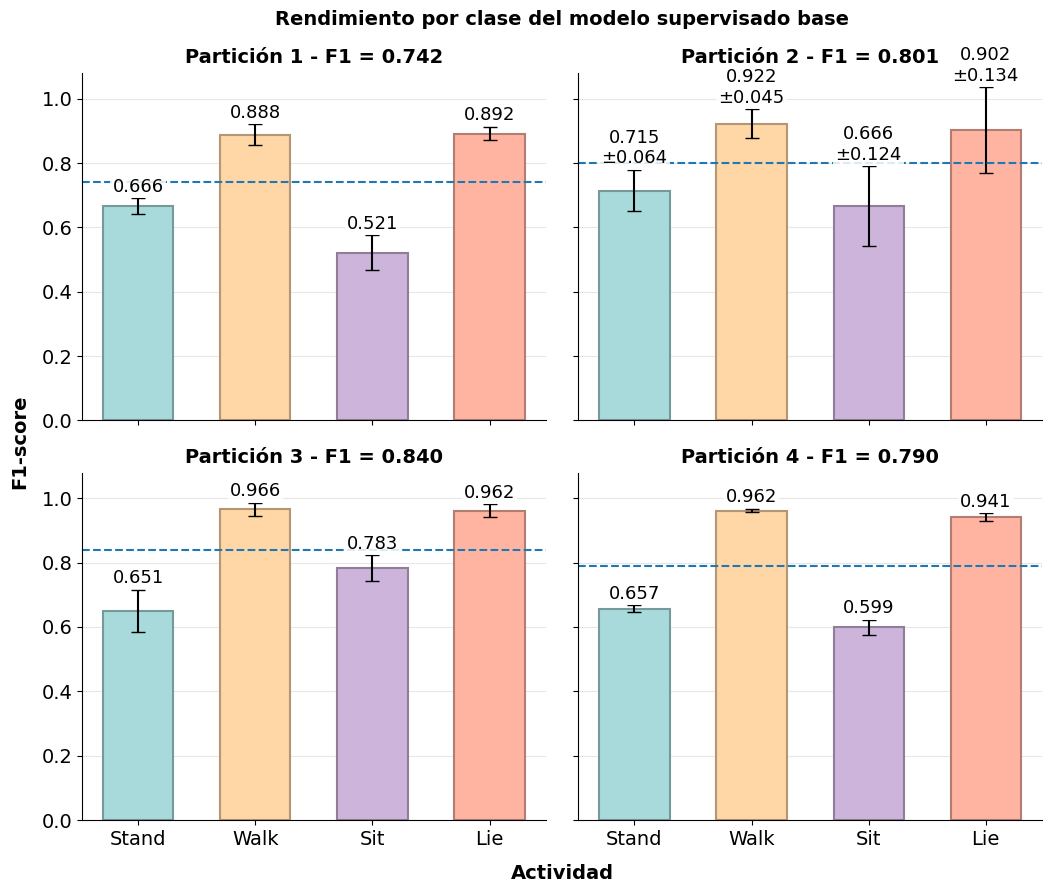

In [209]:
# FOR THESIS — F1-score per class by split
colors = ["#A8DADC", "#FFD6A5", "#CDB4DB", "#FFB4A2"]
classes = ["Stand", "Walk", "Sit", "Lie"]

def darken(color, factor): 
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)

def per_class_f1_from_cm(cm):
    cm = np.asarray(cm, dtype=float)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)
    return f1

for config_name, base_dir in configs.items():
    all_folds = load_folds_results(base_dir, dataset_name, n_folds)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True, sharex=True)
    fig.suptitle(f"Rendimiento por clase del modelo supervisado base", fontweight="bold", fontsize=14) #- {config_name}

    axes = axes.ravel()
    edge_colors = [darken(c, 0.7) for c in colors]

    for idx, fold_idx in enumerate(range(1, n_folds + 1)):  
        reorder_idx = [2, 3, 1, 0]  # CM order: LIE=0,SIT=1,STAND=2,WALK=3 -> display: Stand,Walk,Sit,Lie
        seed_f1_scores = np.array([per_class_f1_from_cm(s["summary"]["test_conf_matrix"])[reorder_idx] for s in all_folds[fold_idx]["runs"].values()])
        mean_f1 = seed_f1_scores.mean(axis=0)
        std_f1 = seed_f1_scores.std(axis=0)
        avg_f1 = mean_f1.mean()

        bars = axes[idx].bar(classes, mean_f1, yerr=std_f1, width=0.6, capsize=5, color=colors, linewidth=0.8)

        for bar, ec in zip(bars, edge_colors):
            bar.set_edgecolor(ec)
            bar.set_linewidth(1.5)

        axes[idx].axhline(avg_f1, linestyle="--", linewidth=1.5)

        #for bar, val, err in zip(bars, mean_f1, std_f1):
        for i, (bar, val, err) in enumerate(zip(bars, mean_f1, std_f1)):
            #axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + err + 0.008, f"{val:.3f}", ha="center", va="bottom", fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))
            label = f"{val:.3f}\n±{err:.3f}" if (i == 2 and fold_idx == 2) or (i == 0 and fold_idx == 2) or (i == 3 and fold_idx == 2) or (i == 1 and fold_idx == 2) else f"{val:.3f}"
            axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + err + 0.008, label, ha="center", va="bottom", fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))
            
        axes[idx].set_title(f"Partición {fold_idx} - F1 = {avg_f1:.3f}", fontweight="bold", fontsize=14, pad=7)
        axes[idx].tick_params(axis="x", rotation=0, labelsize=14)
        axes[idx].tick_params(axis="y", rotation=0, labelsize=14)
        axes[idx].grid(axis="y", alpha=0.3)
        axes[idx].set_axisbelow(True)
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        #axes[idx].legend(loc="upper left", bbox_to_anchor=(0.02, 1.1), frameon=True, fontsize=11, borderpad=0.4, labelspacing=0.4)

    axes[0].set_ylim(0.0, 1.08)

    fig.supylabel("F1-score", fontweight="bold", fontsize=14, x=0.04)
    fig.supxlabel("Actividad", fontweight="bold", fontsize=14)
    fig.subplots_adjust(left=0.10, right=0.9, top=0.91, bottom=0.08, hspace=0.15, wspace=0.07)

    fname = config_name.replace(" ", "_").replace("+", "plus")
    #fig.savefig(f"f1_per_class_{fname}_PAM.png", dpi=600, bbox_inches="tight")
    plt.show()

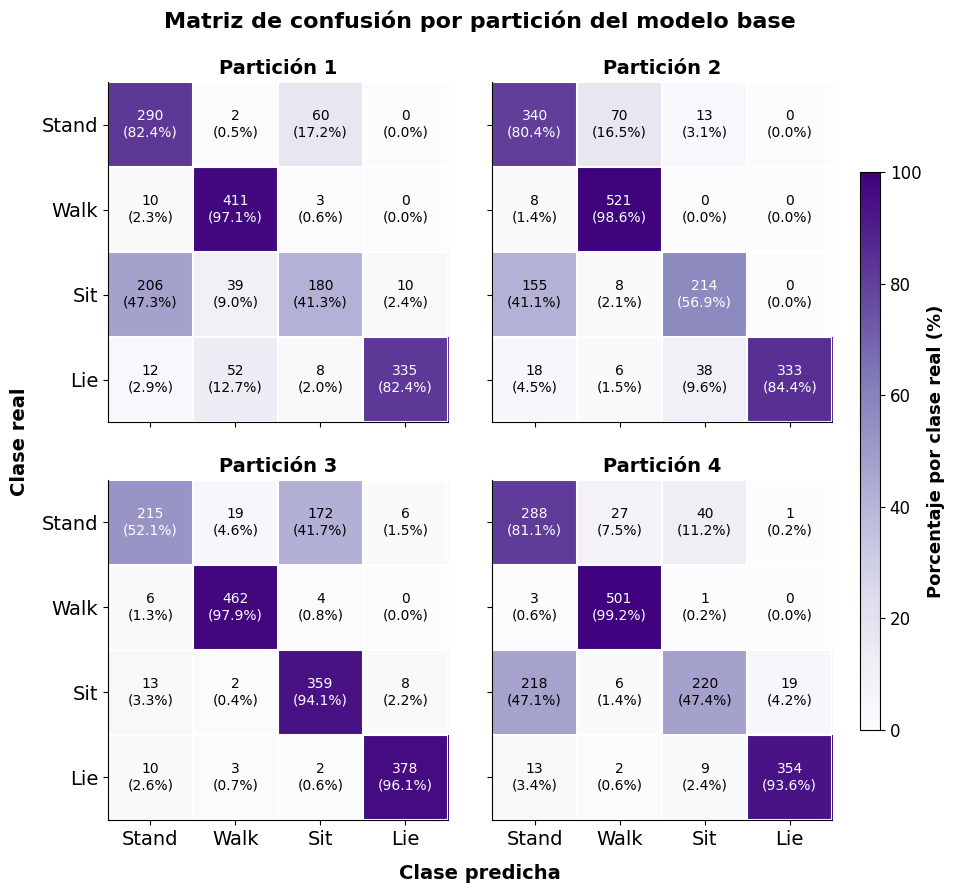

In [207]:
# FOR THESIS — Average confusion matrix by split

classes = ["Stand", "Walk", "Sit", "Lie"]

def mean_confusion_matrix_for_split(fold_results):
    conf_matrices = [np.array(seed_data["summary"]["test_conf_matrix"], dtype=float) for seed_data in fold_results["runs"].values()]
    return np.mean(conf_matrices, axis=0)

for config_name, base_dir in configs.items():
    all_folds = load_folds_results(base_dir, dataset_name, n_folds)

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
    fig.suptitle(f"Matriz de confusión por partición del modelo base", fontweight="bold", fontsize=16) 

    axes = axes.ravel()

    for idx, fold_idx in enumerate(range(1, n_folds + 1)):
        reorder_idx = [2, 3, 1, 0]  # CM order: LIE=0,SIT=1,STAND=2,WALK=3 -> display: Stand,Walk,Sit,Lie
        mean_cm = mean_confusion_matrix_for_split(all_folds[fold_idx])
        mean_cm = mean_cm[np.ix_(reorder_idx, reorder_idx)]
        row_sums = mean_cm.sum(axis=1, keepdims=True)
        cm_pct = np.divide(mean_cm, row_sums, out=np.zeros_like(mean_cm), where=row_sums != 0) * 100

        im = axes[idx].imshow(cm_pct, vmin=0, vmax=100, cmap="Purples")

        axes[idx].set_xticks(np.arange(len(classes)))
        axes[idx].set_yticks(np.arange(len(classes)))
        axes[idx].set_xticklabels(classes, fontsize=14)
        axes[idx].set_yticklabels(classes, fontsize=14)
        axes[idx].tick_params(axis="x", rotation=0, labelsize=14)
        axes[idx].tick_params(axis="y", rotation=0, labelsize=14)
        axes[idx].set_title(f"Partición {fold_idx}", fontweight="bold", fontsize=14)

        for i in range(len(classes)):
            for j in range(len(classes)):
                label = f"{mean_cm[i, j]:.0f}\n({cm_pct[i, j]:.1f}%)"
                text_color = "white" if cm_pct[i, j] > 50 else "black"
                axes[idx].text(j, i, label, ha="center", va="center", fontsize=10, color=text_color)

        axes[idx].set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
        axes[idx].set_yticks(np.arange(-0.5, len(classes), 1), minor=True)
        axes[idx].grid(which="minor", color="white", linestyle="-", linewidth=1.5)
        axes[idx].tick_params(which="minor", bottom=False, left=False)
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)

    fig.supylabel("Clase real", fontweight="bold", fontsize=14, x=0.03)
    fig.supxlabel("Clase predicha", fontweight="bold", fontsize=14)
    
    fig.subplots_adjust(left=0.12, right=0.86, top=0.90, bottom=0.08, hspace=0.17, wspace=0.08)
    
    cbar_ax = fig.add_axes([0.88, 0.18, 0.02, 0.62])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Porcentaje por clase real (%)", fontsize=13, fontweight="bold")
    cbar.ax.tick_params(labelsize=12)
    
    fname = config_name.replace(" ", "_").replace("+", "plus")
    #fig.savefig(f"cm_grid_{fname}.png", dpi=600, bbox_inches="tight")
    plt.show()

# 4.1.3